## Differential Gene Expression Analyse (TCGA BRCA & LUAD) with pydeseq2


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference


In [3]:
import os
filepath = "C:\\Users\\HP\\Documents\\Project\\transcriptome_profiling"
os.chdir(filepath)

## Read and process data and metadata files

In [4]:


counts = pd.read_csv("rna_seq_counts.csv", index_col=0)
meta = pd.read_csv("rna_seq_metadata.csv")

# Metadata mit 'File Name' als Index versehen, damit sie zum Index von 'counts' passt
meta = meta.set_index("File Name")

print("counts:", counts.shape)
print("meta:  ", meta.shape)
counts.columns = counts.columns.str.replace(' ','_')
meta.columns = meta.columns.str.replace(' ','_')

# Reihenfolge/Uebereinstimmung der Samples pruefen und angleichen
assert set(counts.index) == set(meta.index), "Sample-IDs stimmen zwischen beiden Dateien nicht ueberein!"
meta = meta.loc[counts.index]




counts: (57, 60660)
meta:   (57, 11)


In [5]:
#checks if counts are all integers
counts_int = counts.round(0).astype(int)

# Sanity check: keine negativen Werte
assert (counts_int.values >= 0).all()
counts_int.head()

,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA,...,AL451106.1,AC092910.4,AC073611.1,AC136977.1,AC078856.1,AC008763.4,AL592295.6,AC006486.3,AL391628.1,AP006621.6
sample_name,,,,,,,,,,,,,,,,,,,,,
032e5aa7-8028-48ad-8fe4-6a5cc6aee5cb,75,0,90,19,6,7,24,51,7,18,...,0,0,0,0,0,0,10,0,0,2
068ba2ae-288c-446d-8d17-72445ce4f788,55,0,127,11,12,18,52,44,18,47,...,0,0,1,0,0,0,14,0,0,1
08429604-2dc7-4827-8ba5-80818aa45a51,30,4,90,10,5,14,100,49,17,43,...,0,0,0,0,0,0,7,0,0,1
09c3168a-9886-4095-a5ef-8bdcd0988dea,56,1,88,15,8,8,8,46,41,33,...,0,0,0,0,0,0,24,0,0,1
13fc37db-3160-4e82-bd63-52fc295e0e19,95,0,110,22,10,4,12,54,7,60,...,0,0,0,0,0,0,20,0,0,1


In [6]:
def run_deseq2_for_project(project_id, counts_df, meta_df, min_total_count=10):
    """Fuehrt eine DESeq2-DGE-Analyse (Tumor vs. Normal) fuer ein einzelnes TCGA-Projekt durch."""

    sub_meta = meta_df.loc[meta_df["Project_ID"] == project_id].copy()
    sub_counts = counts_df.loc[sub_meta.index]

    print(f"\n=== {project_id} ===")
    print(sub_meta["Tissue_Type"].value_counts())

    # Design-Faktor als kategorische Variable mit 'Normal' als Referenzlevel
    sub_meta["Tissue_Type"] = pd.Categorical(
        sub_meta["Tissue_Type"], categories=["Normal", "Tumor"]
    )

    # Low-count Gene rausfiltern
    keep = sub_counts.sum(axis=0) >= min_total_count
    sub_counts = sub_counts.loc[:, keep]
    print(f"Gene nach Filter (Summe >= {min_total_count}): {sub_counts.shape[1]} von {counts_df.shape[1]}")

    inference = DefaultInference(n_cpus=4)
    dds = DeseqDataSet(
        counts=sub_counts,
        metadata=sub_meta,
        design="~Tissue_Type",
        refit_cooks=True,
        inference=inference,
    )
    dds.deseq2()

    stat_res = DeseqStats(
        dds,
        contrast=["Tissue_Type", "Tumor", "Normal"],
        inference=inference,
    )
    stat_res.summary()

    results_df = stat_res.results_df.sort_values("padj")
    return dds, stat_res, results_df


## Analysis for TCGA-BRCA


In [7]:
dds_brca, stat_brca, res_brca = run_deseq2_for_project("TCGA-BRCA", counts_int, meta)
res_brca.head(20)



=== TCGA-BRCA ===
Tissue_Type
Tumor     27
Normal     3
Name: count, dtype: int64
Gene nach Filter (Summe >= 10): 28852 von 60660
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.16 seconds.

Fitting dispersions...
... done in 28.48 seconds.

Fitting dispersion trend curve...
... done in 1.47 seconds.

Fitting MAP dispersions...
... done in 42.71 seconds.

Fitting LFCs...
... done in 30.09 seconds.

Calculating cook's distance...
... done in 0.31 seconds.

Replacing 3442 outlier genes.

Fitting dispersions...
... done in 4.05 seconds.

Fitting MAP dispersions...
... done in 3.11 seconds.

Fitting LFCs...
... done in 2.13 seconds.

Running Wald tests...
... done in 6.08 seconds.



Log2 fold change & Wald test p-value: Tissue_Type Tumor vs Normal
              baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6       37.483835       -0.714417  0.489630 -1.459095  0.144539  0.704604
TNMD          5.009903       -5.091138  1.185475 -4.294597  0.000018  0.002123
DPM1        100.304638        0.421644  0.304797  1.383360  0.166554  0.734855
SCYL3        14.515781        0.778938  0.426967  1.824350  0.068099  0.531846
C1orf112      7.299893        1.454193  0.598160  2.431110  0.015053  0.246561
...                ...             ...       ...       ...       ...       ...
AL133351.4    1.776673       -0.331816  0.718858 -0.461587  0.644377  0.934394
AC092910.4    0.927875        0.431308  2.759755  0.156285  0.875809  0.977212
AC078856.1    0.382208        0.734546  5.212231  0.140927  0.887927       NaN
AL592295.6   15.043277        0.116622  0.417248  0.279501  0.779860  0.960966
AP006621.6    1.289404        0.835569  1.194946  0.699253  0.484

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
VEGFD,8.513559,-5.867822,0.684479,-8.572680,1.011039e-17,2.109837e-13
GPAM,35.315734,-4.492160,0.634212,-7.083054,1.410116e-12,1.471315e-08
KCNMB1,4.508508,-2.894891,0.412245,-7.022261,2.183062e-12,1.518538e-08
ACSS2,34.618955,-2.022521,0.295330,-6.848342,7.471081e-12,3.897663e-08
GSN,196.163453,-2.777298,0.427492,-6.496721,8.208945e-11,3.426085e-07
MMP11,270.215761,5.283090,0.818046,6.458180,1.059695e-10,3.685620e-07
LPL,160.769135,-5.409262,0.846249,-6.392047,1.636791e-10,4.879509e-07
SIK2,23.561726,-2.599035,0.408056,-6.369309,1.898811e-10,4.953049e-07
MAMDC2,5.518369,-2.851077,0.450908,-6.322965,2.565916e-10,5.949503e-07
KLHL13,5.136188,-3.452453,0.559133,-6.174655,6.630824e-10,1.153100e-06


## 5. Analysis for TCGA-LUAD


In [8]:
dds_luad, stat_luad, res_luad = run_deseq2_for_project("TCGA-LUAD", counts_int, meta)
res_luad.head(20)



=== TCGA-LUAD ===
Tissue_Type
Tumor     23
Normal     4
Name: count, dtype: int64
Gene nach Filter (Summe >= 10): 23892 von 60660
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.11 seconds.

Fitting dispersions...
... done in 27.61 seconds.

Fitting dispersion trend curve...
... done in 2.08 seconds.

Fitting MAP dispersions...
... done in 33.73 seconds.

Fitting LFCs...
... done in 17.39 seconds.

Calculating cook's distance...
... done in 0.16 seconds.

Replacing 862 outlier genes.

Fitting dispersions...
... done in 0.93 seconds.

Fitting MAP dispersions...
... done in 1.15 seconds.

Fitting LFCs...
... done in 0.86 seconds.

Running Wald tests...
... done in 5.48 seconds.



Log2 fold change & Wald test p-value: Tissue_Type Tumor vs Normal
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6      56.329363        1.568116  0.393463  3.985419  0.000067  0.001557
DPM1        89.493964        0.222854  0.242573  0.918709  0.358248  0.599634
SCYL3        7.411141        0.504016  0.365894  1.377491  0.168360  0.403780
C1orf112     4.097813        1.917262  0.722831  2.652436  0.007991  0.060313
FGR         27.797984       -2.221405  0.491106 -4.523274  0.000006  0.000226
...               ...             ...       ...       ...       ...       ...
AL133351.4   1.410530        1.057719  0.929533  1.137903  0.255161  0.502590
LNCDAT       0.716717        2.201006  2.497515  0.881279  0.378167       NaN
AC010980.1   0.626685       -0.272293  1.107094 -0.245953  0.805718       NaN
AL592295.6  10.619438        0.422236  0.383259  1.101699  0.270593  0.517753
AP006621.6   0.589839        1.882722  1.807344  1.041707  0.297548       Na

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
RTKN2,19.984543,-5.223227,0.394938,-13.225448,6.256307e-40,1.167239e-35
PRX,11.545109,-3.911857,0.324196,-12.066326,1.590796e-33,1.483974e-29
LGI3,12.380868,-6.868164,0.606349,-11.327083,9.636071e-30,5.992673e-26
TNNC1,50.092577,-4.762018,0.436609,-10.906832,1.069172e-27,4.986888e-24
KANK3,6.957012,-3.080869,0.314661,-9.791076,1.229801e-22,4.588878e-19
GPM6A,5.682367,-6.626346,0.681501,-9.723166,2.401949e-22,7.468859e-19
SEMA3G,13.590537,-3.660289,0.387350,-9.449567,3.402349e-21,7.934704e-18
PRKCE,8.017830,-2.579583,0.272913,-9.452032,3.323148e-21,7.934704e-18
KCNK3,8.869585,-3.758994,0.401373,-9.365336,7.580859e-21,1.571512e-17
CPB2,4.951400,-5.771646,0.617212,-9.351155,8.669590e-21,1.617485e-17


## Save the results


In [9]:
res_brca.to_csv("deseq2_results_BRCA.csv")
res_luad.to_csv("deseq2_results_LUAD.csv")
print("Gespeichert: deseq2_results_BRCA.csv, deseq2_results_LUAD.csv")


Gespeichert: deseq2_results_BRCA.csv, deseq2_results_LUAD.csv


In [5]:
res_brca = pd.read_csv("deseq2_results_BRCA.csv")
res_luad = pd.read_csv("deseq2_results_LUAD.csv")

## Volcano Plots of each experimenatal condition

TCGA-BRCA: 503 signifikante Gene (padj < 0.05, |log2FC| > 1.0) von 20868 getesteten Genen


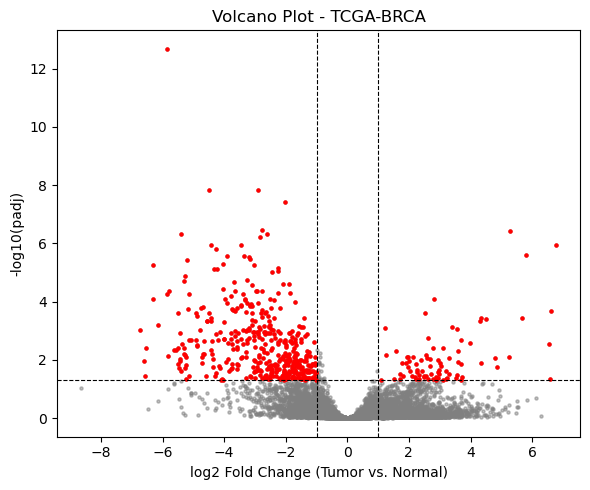

TCGA-LUAD: 1989 signifikante Gene (padj < 0.05, |log2FC| > 1.0) von 18657 getesteten Genen


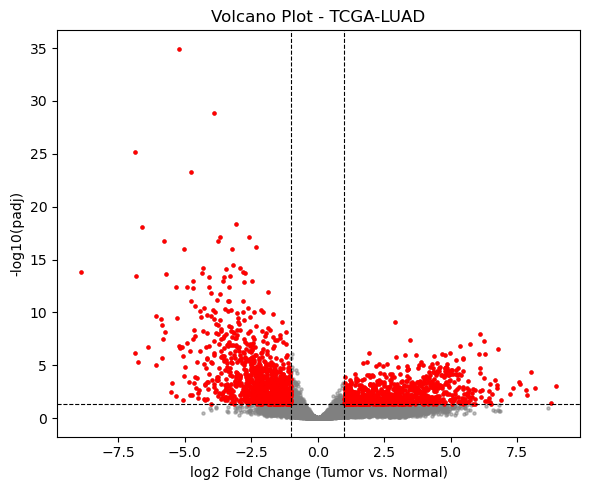

In [10]:
def summarize_and_plot(results_df, project_name, padj_cutoff=0.05, lfc_cutoff=1.0):
    # constructs new data frame containing only significant genes
    df = results_df.dropna(subset=["padj"]).copy()
    sig = df[(df["padj"] < padj_cutoff) & (df["log2FoldChange"].abs() > lfc_cutoff)]
    print(f"{project_name}: {len(sig)} signifikante Gene "
          f"(padj < {padj_cutoff}, |log2FC| > {lfc_cutoff}) von {len(df)} getesteten Genen")
    # constructs volcano plor basen on the previously generated results
    plt.figure(figsize=(6, 5))
    plt.scatter(df["log2FoldChange"], -np.log10(df["padj"]), s=5, color="grey", alpha=0.5)
    plt.scatter(sig["log2FoldChange"], -np.log10(sig["padj"]), s=5, color="red")
    plt.axvline(lfc_cutoff, color="black", linestyle="--", linewidth=0.8)
    plt.axvline(-lfc_cutoff, color="black", linestyle="--", linewidth=0.8)
    plt.axhline(-np.log10(padj_cutoff), color="black", linestyle="--", linewidth=0.8)
    plt.xlabel("log2 Fold Change (Tumor vs. Normal)")
    plt.ylabel("-log10(padj)")
    plt.title(f"Volcano Plot - {project_name}")
    plt.tight_layout()
    plt.show()

    return sig

sig_brca = summarize_and_plot(res_brca, "TCGA-BRCA")
sig_luad = summarize_and_plot(res_luad, "TCGA-LUAD")


## Summary for each result

In [11]:
print(f'BRCA number of significant genes: {sig_brca.shape[0]}')
print(f'BRCA number of upregulated genes: {sig_brca[sig_brca['log2FoldChange'] > 0].shape[0]}')
print(f'BRCA number of downregulated genes: {sig_brca[sig_brca['log2FoldChange'] < 0].shape[0]}')

print(f"LUAD number of significant genes: {sig_luad.shape[0]}")
print(f'LUAD number of upregulated genes: {sig_luad[sig_luad['log2FoldChange'] > 0].shape[0]}')
print(f'LUAD number of downregulated genes: {sig_luad[sig_luad['log2FoldChange'] < 0].shape[0]}')

BRCA number of significant genes: 503
BRCA number of upregulated genes: 81
BRCA number of downregulated genes: 422
LUAD number of significant genes: 1989
LUAD number of upregulated genes: 903
LUAD number of downregulated genes: 1086


## PCA across all samples

In [12]:
from sklearn.decomposition import PCA
import seaborn as sns

# Combined model across both projects, only used to get consistent size-factor normalized counts
keep_all = counts_int.sum(axis=0) >= 10
counts_all_filt = counts_int.loc[:, keep_all]

meta_all = meta.copy()
meta_all["Project_ID"] = pd.Categorical(meta_all["Project_ID"])
meta_all["Tissue_Type"] = pd.Categorical(meta_all["Tissue_Type"], categories=["Normal", "Tumor"])

inference_all = DefaultInference(n_cpus=4)
dds_all = DeseqDataSet(
    counts=counts_all_filt,
    metadata=meta_all,
    design="~Project_ID + Tissue_Type",
    refit_cooks=True,
    inference=inference_all,
)
dds_all.deseq2()


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.45 seconds.

Fitting dispersions...
... done in 37.28 seconds.

Fitting dispersion trend curve...
... done in 5.39 seconds.

Fitting MAP dispersions...
... done in 67.99 seconds.

Fitting LFCs...
... done in 32.09 seconds.

Calculating cook's distance...
... done in 0.50 seconds.

Replacing 3089 outlier genes.

Fitting dispersions...
... done in 3.41 seconds.

Fitting MAP dispersions...
... done in 2.79 seconds.

Fitting LFCs...
... done in 2.64 seconds.



In [14]:
# log2-transform the size-factor normalized counts (used for both PCA and the heatmap below)
normed_counts = dds_all.layers["normed_counts"]
log2_counts = pd.DataFrame(
    np.log2(normed_counts + 1),
    index=counts_all_filt.index,
    columns=counts_all_filt.columns,
)

# use the top 500 most variable genes for the PCA
top_var_genes = log2_counts.var(axis=0).sort_values(ascending=False).head(500).index
pca_input = log2_counts[top_var_genes]

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(pca_input)

pca_df = pd.DataFrame(pca_coords, columns=["PC1", "PC2"], index=log2_counts.index)
pca_df["Project_ID"] = meta_all["Project_ID"].values
pca_df["Tissue_Type"] = meta_all["Tissue_Type"].values

print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")
pca_df.head()


Explained variance ratio: PC1=37.77%, PC2=13.39%


,PC1,PC2,Project_ID,Tissue_Type
sample_name,,,,
032e5aa7-8028-48ad-8fe4-6a5cc6aee5cb,-11.038055,-31.165792,TCGA-BRCA,Tumor
068ba2ae-288c-446d-8d17-72445ce4f788,47.420781,-3.916823,TCGA-LUAD,Tumor
08429604-2dc7-4827-8ba5-80818aa45a51,-1.170018,-40.764783,TCGA-BRCA,Tumor
09c3168a-9886-4095-a5ef-8bdcd0988dea,-42.002571,-11.641533,TCGA-BRCA,Tumor
13fc37db-3160-4e82-bd63-52fc295e0e19,-52.891041,7.327778,TCGA-BRCA,Tumor


### Scree plot

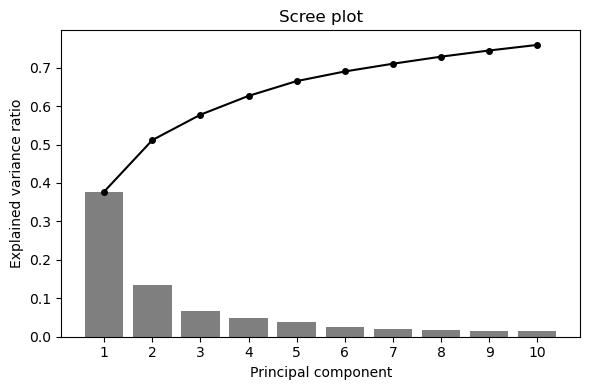

In [15]:
pca_full = PCA(n_components=10)
pca_full.fit(pca_input)

plt.figure(figsize=(6, 4))
components = np.arange(1, len(pca_full.explained_variance_ratio_) + 1)
plt.bar(components, pca_full.explained_variance_ratio_, color="tab:grey")
plt.plot(components, np.cumsum(pca_full.explained_variance_ratio_), color="black", marker="o", markersize=4)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Scree plot")
plt.xticks(components)
plt.tight_layout()
plt.show()


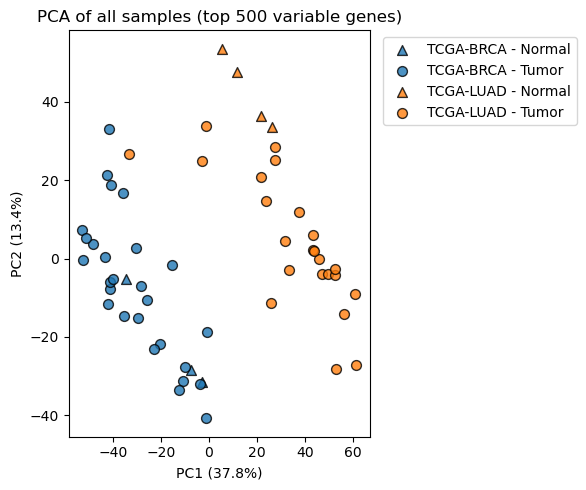

In [16]:
# scatter plot: color by project, marker shape by tissue type
color_map = {"TCGA-BRCA": "tab:blue", "TCGA-LUAD": "tab:orange"}
marker_map = {"Tumor": "o", "Normal": "^"}

plt.figure(figsize=(6, 5))
for project, sub in pca_df.groupby("Project_ID"):
    for tissue, sub2 in sub.groupby("Tissue_Type"):
        plt.scatter(
            sub2["PC1"], sub2["PC2"],
            c=color_map[project], marker=marker_map[tissue],
            label=f"{project} - {tissue}", s=50, edgecolor="black", alpha=0.8,
        )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
plt.title("PCA of all samples (top 500 variable genes)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


### PCA with 95% confidence ellipses

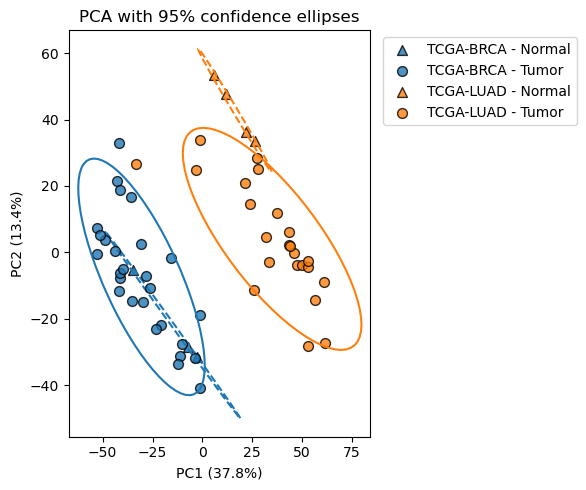

In [17]:
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
from scipy import stats

def plot_confidence_ellipse(x, y, ax, n_std=1.96, **kwargs):
    """Draws a confidence ellipse (default 1.96 std -> ~95%) for the given x/y points onto ax."""
    if len(x) < 3:
        # not enough points to estimate a covariance matrix
        return
    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])

    radius_x = np.sqrt(1 + pearson)
    radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=radius_x * 2, height=radius_y * 2, facecolor="none", **kwargs)

    scale_x = np.sqrt(cov[0, 0]) * n_std
    scale_y = np.sqrt(cov[1, 1]) * n_std
    transf = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(np.mean(x), np.mean(y))
    )
    ellipse.set_transform(transf + ax.transData)
    ax.add_patch(ellipse)

fig, ax = plt.subplots(figsize=(6, 5))
for project, sub in pca_df.groupby("Project_ID"):
    for tissue, sub2 in sub.groupby("Tissue_Type"):
        ax.scatter(
            sub2["PC1"], sub2["PC2"],
            c=color_map[project], marker=marker_map[tissue],
            label=f"{project} - {tissue}", s=50, edgecolor="black", alpha=0.8,
        )
        plot_confidence_ellipse(
            sub2["PC1"].values, sub2["PC2"].values, ax,
            n_std=1.96, edgecolor=color_map[project],
            linestyle="--" if tissue == "Normal" else "-",
            linewidth=1.5,
        )

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
ax.set_title("PCA with 95% confidence ellipses")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Heatmap of top differentially expressed genes

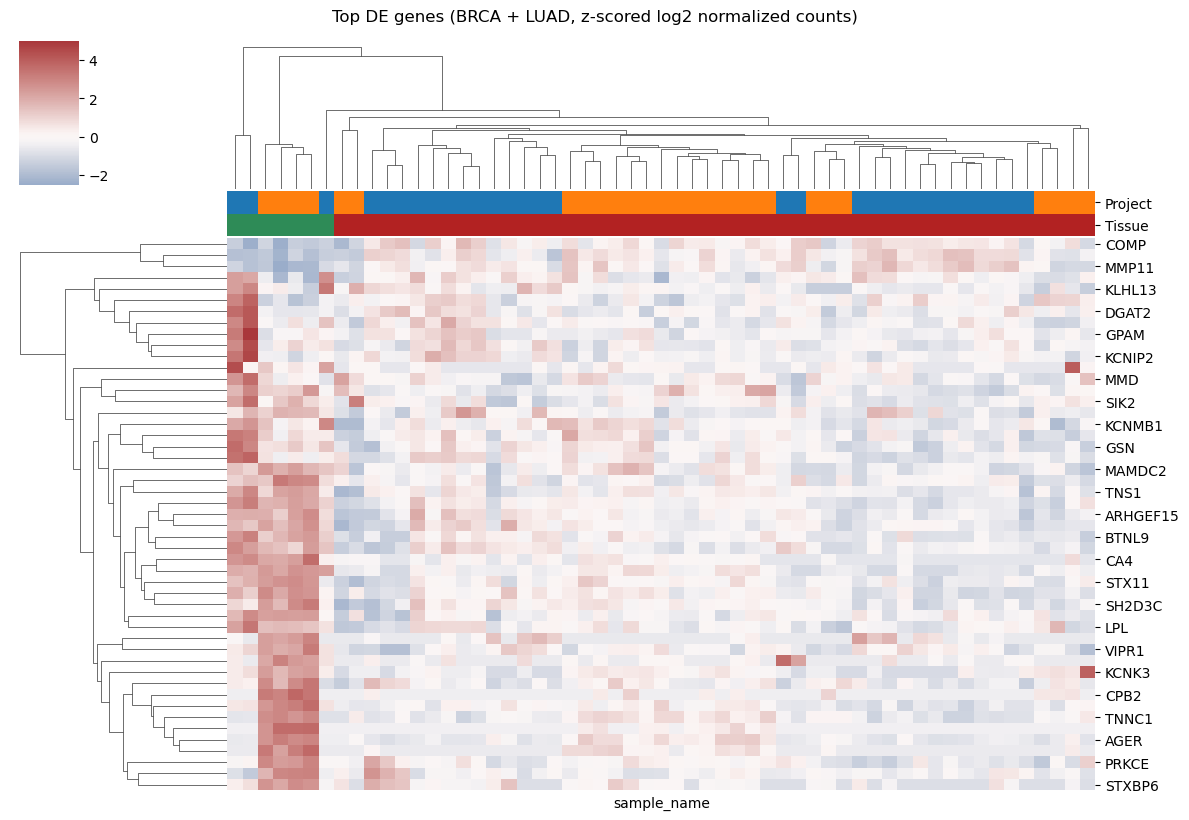

In [18]:
n_top = 25
top_genes_brca = res_brca.dropna(subset=["padj"]).sort_values("padj").head(n_top).index
top_genes_luad = res_luad.dropna(subset=["padj"]).sort_values("padj").head(n_top).index
heatmap_genes = pd.Index(sorted(set(top_genes_brca) | set(top_genes_luad)))

heatmap_data = log2_counts[heatmap_genes].T

# z-score each gene (row) across samples so the heatmap shows relative expression per gene
heatmap_data_z = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0).div(heatmap_data.std(axis=1), axis=0)

# column color annotations for project and tissue type
project_colors = meta_all["Project_ID"].map(color_map)
tissue_colors = meta_all["Tissue_Type"].map({"Tumor": "firebrick", "Normal": "seagreen"})
col_colors = pd.DataFrame({"Project": project_colors.values, "Tissue": tissue_colors.values}, index=meta_all.index)

g = sns.clustermap(
    heatmap_data_z,
    col_colors=col_colors,
    cmap="vlag",
    center=0,
    figsize=(12, 8),
    xticklabels=False,
)
g.fig.suptitle("Top DE genes (BRCA + LUAD, z-scored log2 normalized counts)", y=1.02)
plt.show()


In [19]:
print("BRCA results index:", res_brca.index[:5])
print("LUAD results index:", res_luad.index[:5])
print("log2_counts columns:", log2_counts.columns[:5])

BRCA results index: Index(['VEGFD', 'GPAM', 'KCNMB1', 'ACSS2', 'GSN'], dtype='object')
LUAD results index: Index(['RTKN2', 'PRX', 'LGI3', 'TNNC1', 'KANK3'], dtype='object')
log2_counts columns: Index(['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112'], dtype='object')


## LUAD vs. BRCA comparison

Two complementary comparisons:
1. Overlap of the significant genes found in the two separate tumor-vs-normal analyses (BRCA and LUAD).
2. A direct differential expression analysis between BRCA and LUAD tumors.


### 1. Overlap of significant genes (BRCA tumor-vs-normal vs. LUAD tumor-vs-normal)


Significant in both BRCA and LUAD: 495
Significant only in BRCA: 8
Significant only in LUAD: 1494


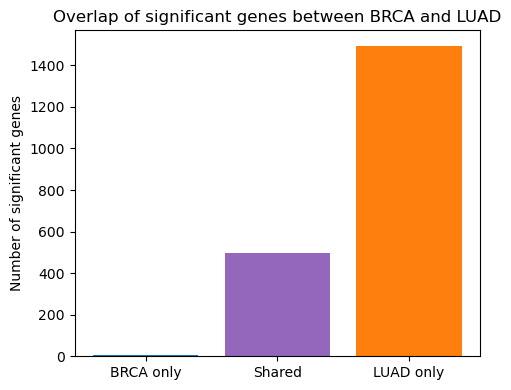

In [21]:
brca_sig_genes = set(sig_brca.index)
luad_sig_genes = set(sig_luad.index)

shared_genes = brca_sig_genes & luad_sig_genes
brca_only_genes = brca_sig_genes - luad_sig_genes
luad_only_genes = luad_sig_genes - brca_sig_genes

print(f"Significant in both BRCA and LUAD: {len(shared_genes)}")
print(f"Significant only in BRCA: {len(brca_only_genes)}")
print(f"Significant only in LUAD: {len(luad_only_genes)}")

plt.figure(figsize=(5, 4))
plt.bar(
    ["BRCA only", "Shared", "LUAD only"],
    [len(brca_only_genes), len(shared_genes), len(luad_only_genes)],
    color=["tab:blue", "tab:purple", "tab:orange"],
)
plt.ylabel("Number of significant genes")
plt.title("Overlap of significant genes between BRCA and LUAD")
plt.tight_layout()
plt.show()


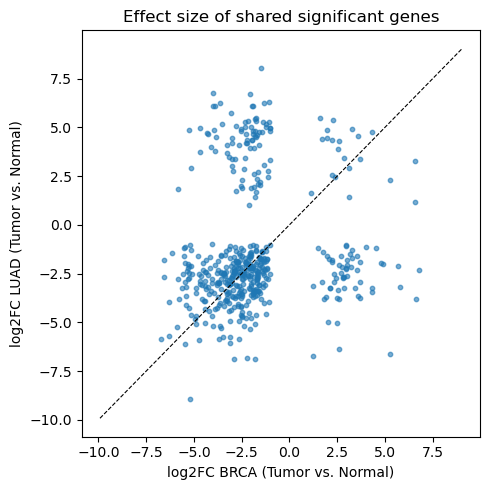

348 of 495 shared significant genes change in the same direction in both cancer types.


In [22]:
# for genes significant in both, compare the direction/magnitude of the effect (log2FC)
shared_fc = pd.DataFrame({
    "log2FC_BRCA": res_brca.loc[list(shared_genes), "log2FoldChange"],
    "log2FC_LUAD": res_luad.loc[list(shared_genes), "log2FoldChange"],
})

plt.figure(figsize=(5, 5))
plt.scatter(shared_fc["log2FC_BRCA"], shared_fc["log2FC_LUAD"], s=10, alpha=0.6)
lims = [shared_fc.values.min() - 1, shared_fc.values.max() + 1]
plt.plot(lims, lims, color="black", linestyle="--", linewidth=0.8)
plt.xlabel("log2FC BRCA (Tumor vs. Normal)")
plt.ylabel("log2FC LUAD (Tumor vs. Normal)")
plt.title("Effect size of shared significant genes")
plt.tight_layout()
plt.show()

same_direction = (np.sign(shared_fc["log2FC_BRCA"]) == np.sign(shared_fc["log2FC_LUAD"])).sum()
print(f"{same_direction} of {len(shared_fc)} shared significant genes change in the same direction "
      "in both cancer types.")


### 2. Direct differential expression: BRCA tumors vs. LUAD tumors


In [23]:
tumor_meta = meta.loc[meta["Tissue_Type"] == "Tumor"].copy()
tumor_counts = counts_int.loc[tumor_meta.index]

tumor_meta["Project_ID"] = pd.Categorical(tumor_meta["Project_ID"], categories=["TCGA-LUAD", "TCGA-BRCA"])

keep_tumor = tumor_counts.sum(axis=0) >= 10
tumor_counts = tumor_counts.loc[:, keep_tumor]

inference_tumor = DefaultInference(n_cpus=4)
dds_tumor = DeseqDataSet(
    counts=tumor_counts,
    metadata=tumor_meta,
    design="~Project_ID",
    refit_cooks=True,
    inference=inference_tumor,
)
dds_tumor.deseq2()

stat_tumor = DeseqStats(
    dds_tumor,
    contrast=["Project_ID", "TCGA-BRCA", "TCGA-LUAD"],
    inference=inference_tumor,
)
stat_tumor.summary()

res_brca_vs_luad = stat_tumor.results_df.sort_values("padj")
res_brca_vs_luad.to_csv("deseq2_results_BRCA_vs_LUAD.csv")
res_brca_vs_luad.head(20)


Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.29 seconds.

Fitting dispersions...
... done in 29.14 seconds.

Fitting dispersion trend curve...
... done in 2.20 seconds.

Fitting MAP dispersions...
... done in 49.65 seconds.

Fitting LFCs...
... done in 32.86 seconds.

Calculating cook's distance...
... done in 0.42 seconds.

Replacing 4079 outlier genes.

Fitting dispersions...
... done in 3.48 seconds.

Fitting MAP dispersions...
... done in 3.94 seconds.

Fitting LFCs...
... done in 2.74 seconds.

Running Wald tests...
... done in 7.94 seconds.



Log2 fold change & Wald test p-value: Project_ID TCGA-BRCA vs TCGA-LUAD
             baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
TSPAN6      48.945197       -1.017483  0.219346 -4.638715  0.000004  0.000064
TNMD         0.667339        2.102417  0.990965  2.121585  0.033873  0.105639
DPM1        97.815078       -0.020397  0.135135 -0.150937  0.880025  0.930577
SCYL3       11.565241        0.788073  0.173647  4.538370  0.000006  0.000095
C1orf112     6.265062        0.515769  0.215923  2.388677  0.016909  0.062975
...               ...             ...       ...       ...       ...       ...
AC092910.4   0.512855        2.039423  1.830094  1.114382  0.265115       NaN
AC073611.1   0.219220       -0.644382  1.094370 -0.588816  0.555985       NaN
AC078856.1   0.314382        0.159435  2.569506  0.062049  0.950524       NaN
AL592295.6  13.214427        0.271904  0.191384  1.420724  0.155397  0.311669
AP006621.6   1.035232        0.683332  0.489175  1.396905  0.162442  0

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
SFTPB,2149.051873,-13.863840,0.750196,-18.480301,2.975170e-76,6.784577e-72
SFTPA2,1477.631767,-11.757740,0.667816,-17.606257,2.205581e-69,2.514804e-65
GATA3,283.956148,6.387404,0.377801,16.906815,4.007942e-64,3.046571e-60
NAPSA,264.922810,-10.294198,0.673827,-15.277217,1.084760e-52,6.184215e-49
SFTPA1,1022.654111,-13.433728,0.883065,-15.212613,2.916633e-52,1.330218e-48
TRPS1,84.411451,4.383463,0.304703,14.386008,6.334880e-47,2.407677e-43
TESC,119.765827,-6.344425,0.491694,-12.903211,4.317247e-38,1.406436e-34
SFTA2,131.770024,-8.495839,0.667044,-12.736551,3.704090e-37,1.055851e-33
C4BPA,164.198895,-9.103617,0.717815,-12.682397,7.403248e-37,1.875818e-33
ST6GALNAC1,26.514717,-4.693193,0.406860,-11.535153,8.773113e-31,2.000621e-27


In [ ]:
sig_brca_vs_luad = res_brca_vs_luad.dropna(subset=["padj"])
sig_brca_vs_luad = sig_brca_vs_luad[
    (sig_brca_vs_luad["padj"] < 0.05) & (sig_brca_vs_luad["log2FoldChange"].abs() > 1)
]

print(f"BRCA vs. LUAD (tumor samples only): {len(sig_brca_vs_luad)} significant genes "
      f"(padj < 0.05, |log2FC| > 1)")
print(f"Higher in BRCA: {(sig_brca_vs_luad['log2FoldChange'] > 0).sum()}")
print(f"Higher in LUAD: {(sig_brca_vs_luad['log2FoldChange'] < 0).sum()}")


## Gene enrichment analysis

Over-representation analysis (ORA) of the significant genes from the BRCA and LUAD tumor-vs-normal results, using `gseapy`'s Enrichr interface against GO Biological Process and KEGG gene sets.

**Install once if needed:**
```
pip install gseapy
```
**Note:** `gseapy.enrichr` queries the Enrichr web service, so this needs an internet connection.


In [20]:
import gseapy as gp

gene_sets = ["GO_Biological_Process_2021", "KEGG_2021_Human"]

def run_enrichment(gene_list, label):
    """Runs Enrichr-based over-representation analysis for a list of gene symbols."""
    enr = gp.enrichr(
        gene_list=list(gene_list),
        gene_sets=gene_sets,
        organism="human",
        outdir=None,
    )
    results = enr.results.sort_values("Adjusted P-value")
    n_sig = (results['Adjusted P-value'] < 0.05).sum()
    print(f"{label}: {len(results)} terms tested, {n_sig} significant (padj < 0.05)")
    return results


### Enrichment for BRCA significant genes


In [21]:
enrich_brca = run_enrichment(sig_brca.index, "BRCA")
enrich_brca.head(10)


BRCA: 2952 terms tested, 88 significant (padj < 0.05)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
2702,KEGG_2021_Human,PPAR signaling pathway,12/74,2.992716e-07,0.000075,0,0,7.661126,115.084779,ACSL1;MMP1;SCD;PLIN4;AQP7;LPL;PPARG;ACADM;CD36...
2703,KEGG_2021_Human,Regulation of lipolysis in adipocytes,10/55,9.810653e-07,0.000123,0,0,8.768087,121.303206,LIPE;NPR1;PDE3B;AQP7;PLAAT3;PLIN1;ADRB2;MGLL;G...
0,GO_Biological_Process_2021,positive regulation of cold-induced thermogene...,14/97,1.400798e-07,0.000211,0,0,6.696627,105.679827,OXTR;ACSL1;EPAS1;CAV1;ELOVL3;G0S2;ADRB2;SCD;LE...
1,GO_Biological_Process_2021,positive regulation of metabolic process (GO:0...,15/113,1.560867e-07,0.000211,0,0,6.084497,95.361440,OXTR;ACSL1;EPAS1;CAV1;ELOVL3;G0S2;ADRB2;ACACB;...
2704,KEGG_2021_Human,Glycerolipid metabolism,10/61,2.642807e-06,0.000220,0,0,7.734161,99.334998,DGAT2;ALDH2;GPAM;GLYCTK;LPL;PLPP3;AGPAT2;MGLL;...
2,GO_Biological_Process_2021,regulation of endothelial cell proliferation (...,13/92,5.035887e-07,0.000248,0,0,6.521157,94.566602,STAT5A;CCL24;EGR3;ANGPT1;CAV2;CAV1;VEGFB;PTPRM...
7,GO_Biological_Process_2021,positive regulation of multicellular organisma...,26/345,7.344547e-07,0.000248,0,0,3.276933,46.283856,OXTR;EPAS1;NPR1;SERPINE1;PTN;ADRB2;FGF2;AGPAT2...
3,GO_Biological_Process_2021,sprouting angiogenesis (GO:0002040),10/52,5.677200e-07,0.000248,0,0,9.395827,135.127381,ESM1;EGR3;ANGPT1;VEGFB;RSPO3;ITGB1BP1;PARVA;VE...
5,GO_Biological_Process_2021,external encapsulating structure organization ...,20/217,6.450387e-07,0.000248,0,0,4.056710,57.824162,COL17A1;MMP1;COL11A1;SERPINE1;FN1;BGN;FGF2;COL...
6,GO_Biological_Process_2021,extracellular matrix organization (GO:0030198),24/300,6.792169e-07,0.000248,0,0,3.489335,49.556666,COL17A1;GSN;MMP1;COL11A1;SERPINE1;FN1;BGN;DPT;...


### Enrichment for LUAD significant genes


In [22]:
enrich_luad = run_enrichment(sig_luad.index, "LUAD")
enrich_luad.head(10)


LUAD: 4893 terms tested, 80 significant (padj < 0.05)


,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes
0,GO_Biological_Process_2021,extracellular matrix organization (GO:0030198),63/300,7.436349e-09,0.000034,0,0,2.453133,45.915011,COL18A1;LAMC3;ICAM2;PLOD2;FGF2;LOXL2;COMP;ADAM...
1,GO_Biological_Process_2021,regulation of cell migration (GO:0030334),76/408,5.353752e-08,0.000097,0,0,2.115525,35.419994,SEMA5A;ACVRL1;ROBO4;RIPOR1;FAM107A;ADARB1;LDB2...
2,GO_Biological_Process_2021,microtubule cytoskeleton organization involved...,34/128,6.574454e-08,0.000097,0,0,3.314894,54.820017,BUB1B;CDCA8;TTK;KIF11;CENPA;SKA1;AURKB;AURKA;C...
3,GO_Biological_Process_2021,external encapsulating structure organization ...,48/217,8.499590e-08,0.000097,0,0,2.610794,42.505449,COL17A1;COL18A1;LAMC3;COL11A1;ICAM2;PDGFB;NDNF...
4,GO_Biological_Process_2021,extracellular structure organization (GO:0043062),47/216,1.938828e-07,0.000178,0,0,2.555086,39.491434,COL17A1;COL18A1;LAMC3;COL11A1;ICAM2;PDGFB;NDNF...
5,GO_Biological_Process_2021,regulation of angiogenesis (GO:0045765),44/203,5.269818e-07,0.000403,0,0,2.539936,36.717573,SEMA5A;RAMP2;HSPB6;NPR1;GATA6;ECSCR;PTPRM;GATA...
6,GO_Biological_Process_2021,negative regulation of cell migration (GO:0030...,34/144,1.324979e-06,0.000792,0,0,2.830198,38.304218,ACVRL1;NDRG4;ADARB1;FGF2;CORO1C;PTPRG;ADGRG1;D...
7,GO_Biological_Process_2021,mitotic spindle organization (GO:0007052),36/157,1.380402e-06,0.000792,0,0,2.725368,36.773767,BUB1B;CDCA8;TTK;KIF11;CENPA;SKA1;AURKB;AURKA;C...
8,GO_Biological_Process_2021,maintenance of blood-brain barrier (GO:0035633),13/30,2.107841e-06,0.001064,0,0,6.963622,91.013474,SLC1A1;LSR;CLDN1;TJP1;CDH5;CLDN5;CLDN3;CLDN12;...
9,GO_Biological_Process_2021,regulation of small GTPase mediated signal tra...,33/141,2.319685e-06,0.001064,0,0,2.796708,36.284713,ARHGAP11A;ARHGEF26;ARHGAP18;FOXM1;ARHGAP6;ARHG...


### Bar plots of top enriched terms


In [ ]:
enrich_brca.to_csv("enrichment_results_BRCA.csv", index=False)
enrich_luad.to_csv("enrichment_results_LUAD.csv", index=False)
print("Saved: enrichment_results_BRCA.csv, enrichment_results_LUAD.csv")


In [ ]:
def plot_top_terms(results, title, n_top=10):
    top = results.sort_values("Adjusted P-value").head(n_top).iloc[::-1]
    plt.figure(figsize=(8, 5))
    plt.barh(top["Term"], -np.log10(top["Adjusted P-value"]), color="teal")
    plt.axvline(-np.log10(0.05), color="black", linestyle="--", linewidth=0.8)
    plt.xlabel("-log10(adjusted p-value)")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_top_terms(enrich_brca, "Top enriched terms - BRCA")
plot_top_terms(enrich_luad, "Top enriched terms - LUAD")
